# Data Processing for Regression

In [ ]:
import mod_loading as loader
from importlib import reload

<module 'mod_loading' from '/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CRUSOE/src/mod_loading.py'>

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import datetime

import gsw
import mod_argo

In [64]:
import matplotlib.pyplot as plt
from cmocean import cm as cmo

# Import data

In [3]:
# Results of GMM
# Use bgcArgo and SOCAT data for supervised regression training
reload(loader)
bgcINDEX, bgcDS, socatDS = loader.import_regresssion_data()


In [4]:
# Prepare socatDS
socatDS

<xarray.Dataset>
Dimensions:            (index: 42459)
Coordinates:
  * sid                (index) int64 156 157 158 159 ... 49618 49619 49620 49621
    cluster            (index) float64 ...
Dimensions without coordinates: index
Data variables: (12/26)
    longitude          (index) float64 ...
    latitude           (index) float64 ...
    fco2rec            (index) float64 ...
    sal                (index) float64 ...
    sst                (index) float64 ...
    yearday            (index) float64 ...
    ...                 ...
    yd_sep             (index) float64 ...
    km_sep             (index) float64 ...
    class              (index) float64 ...
    pressure           (index) float64 -0.0 -0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0
    SA                 (index) float64 33.91 33.92 33.97 ... 34.59 34.58 34.64
    CT                 (index) float64 7.517 7.857 8.072 ... 15.41 15.37 15.79

# Mixed layer calculation

In [ ]:
# Moved this to mod_argo.py
# def calc_mlp(platDS, threshold=0.03):  
#     """  
#     Updated method for calculating mlp for each Argo profile
#     Use linear interpolation to find mixed layer pressure between two pressure levels

#     @param:     platDS: xr Dataset with 'profid' as a dimension
#                         (Current version uses 5dbar incremented data)
#                 threshold: Density threshold for mixed layer pressure calculation (default is 0.03 kg/m^3)
#     @return:    prof_mlps: DataFrame with 'profid' as index and 'mlp' as column
#                 no_data: List of profids without valid data 
#     """
#     prof_mlps = pd.DataFrame(index=pd.unique(platDS.profid.values), columns=['mlp'])
#     no_data = [] 
    
#     for id, prof in platDS.to_dataframe().groupby('profid'):
#         prof_df = prof.reset_index().copy()

#         try: # general catch for missing data, technically don't need for our L3 data
#             dens10 = prof_df.loc[prof_df.pressure==10].sigma0.values[0]
#             dens_tofind = dens10 + threshold 
#             mask = prof_df.sigma0.values > dens_tofind

#             if mask.any(): # If any values meet threshold density condition
#                 idx = prof_df.sigma0.index[np.argmax(mask)]
#                 (p0,d0)= (prof_df.pressure[np.argmax(mask)-1], prof_df.sigma0[np.argmax(mask)-1]) # obs just above mlp
#                 (p1,d1)= (prof_df.pressure[np.argmax(mask)], prof_df.sigma0[np.argmax(mask)]) # first obs below mlp

#                 mlp = p1 + (dens_tofind - d1) * ((p1-p0)/(d1-d0)) # Linear interpolation
#                 prof_mlps.loc[id, 'mlp'] = mlp

#             else: 
#                 prof_mlps.loc[id, 'mlp'] = np.nan
#         except: 
#             no_data.append(id)
        
#     return prof_mlps, no_data

In [ ]:
# Calculate mixed layer pressure 
bgc_mlps, no_data = mod_argo.calc_mlp(bgcDS, threshold=0.03)
bgc_mlps['mld'] = gsw.z_from_p(bgc_mlps.mlp.values, bgcINDEX.latitude.values)

# Add mixed layer depth (mld)
bgcINDEX['mld']= -xr.DataArray(bgc_mlps.mld.values, dims='profid') # Notice negative
bgcDS['mld']= -xr.DataArray(bgc_mlps.mld.values, dims='profid') # Notice negative

# Add mixed layer pressure (mlp)
bgcINDEX['mlp'] = xr.DataArray(bgc_mlps.mlp.values, dims='profid')
bgcDS['mlp'] = xr.DataArray(bgc_mlps.mlp.values, dims='profid')


In [202]:
# Get data from single float
reload(mod_argo)
exfloat, _ = mod_argo.get_wmo_DS(bgcDS, wmo='5904477')
calc_mlp(exfloat)

(                      mlp
 5904477_id012   89.996611
 5904477_id013  164.995323
 5904477_id014  104.998005
 5904477_id001   64.998153
 5904477_id002   69.972275
 5904477_id003   74.995194
 5904477_id004   44.997441
 5904477_id005   64.996274
 5904477_id007    74.96895
 5904477_id008   84.991891
 5904477_id009   49.981069
 5904477_id010   25.004717
 5904477_id011   89.998004
 5904477_id015    99.99195
 5904477_id016   94.988513
 5904477_id017   89.990136
 5904477_id018   99.986429,
 [])

In [342]:
temp

,profid,pressure,CT,SA,sigma0,spice,temperature,salinity,yearday,latitude,longitude,pH,oxygen,wmoid,datetime,cluster,mld,mlp
0,2903473_id005,0,8.400988,34.417374,26.631043,0.441594,8.399000,34.255634,3602.256574,-44.8723,-28.4891,8.099631,304.420166,2903473.0,2023-11-12 06:09:28,1.0,38.071603,38.424947
1,2903473_id005,5,8.400988,34.417374,26.631043,0.441594,8.399000,34.255634,3602.256574,-44.8723,-28.4891,8.099631,304.420166,2903473.0,2023-11-12 06:09:28,1.0,38.071603,38.424947
2,2903473_id005,10,8.403945,34.417890,26.631009,0.442450,8.402155,34.256150,3602.256574,-44.8723,-28.4891,8.099621,304.384600,2903473.0,2023-11-12 06:09:28,1.0,38.071603,38.424947
3,2903473_id005,15,8.405104,34.417785,26.630712,0.442564,8.403799,34.256053,3602.256574,-44.8723,-28.4891,8.099201,304.279363,2903473.0,2023-11-12 06:09:28,1.0,38.071603,38.424947
4,2903473_id005,20,8.406499,34.417789,26.630645,0.442739,8.405703,34.256062,3602.256574,-44.8723,-28.4891,8.098334,304.171121,2903473.0,2023-11-12 06:09:28,1.0,38.071603,38.424947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1768,2903473_id006,960,2.701987,34.595505,27.459728,-0.182392,2.763940,34.429209,3612.508785,-44.6008,-27.3142,7.826638,180.723407,2903473.0,2023-11-22 12:12:39,4.0,27.413959,27.654908
1769,2903473_id006,965,2.699422,34.598818,27.462579,-0.180302,2.761756,34.432486,3612.508785,-44.6008,-27.3142,7.826527,180.256244,2903473.0,2023-11-22 12:12:39,4.0,27.413959,27.654908
1770,2903473_id006,970,2.696994,34.602083,27.465379,-0.178230,2.759706,34.435715,3612.508785,-44.6008,-27.3142,7.826434,179.808777,2903473.0,2023-11-22 12:12:39,4.0,27.413959,27.654908
1771,2903473_id006,975,2.694644,34.605300,27.468134,-0.176184,2.757731,34.438897,3612.508785,-44.6008,-27.3142,7.826354,179.380504,2903473.0,2023-11-22 12:12:39,4.0,27.413959,27.654908


5904982


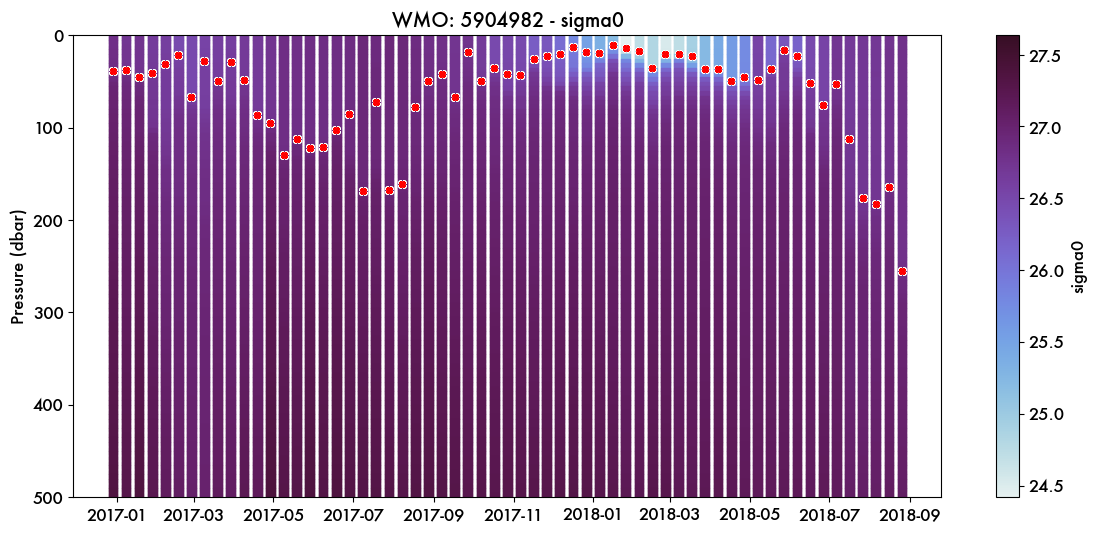

In [375]:
fig = plt.figure(figsize=(14, 6))
ax = fig.gca()


exfloat, wmo = mod_argo.get_wmo_DS(bgcDS)   # Random float
# exfloat, wmo = mod_argo.get_wmo_DS(bgcDS, 5906526)  # Specify float
# exfloat, wmo = mod_argo.get_wmo_DS(bgcDS, wmo)  # Keep float from last run

temp = exfloat.to_dataframe().reset_index().dropna(axis=0, subset=['sigma0', 'pressure'])
sca = ax.scatter(temp['datetime'], temp['pressure'], c=temp['sigma0'], s=40, marker='s',  alpha=1, cmap=cmo.dense)

ax.scatter(temp['datetime'], temp['mlp'], c='w', marker='X', s=25, alpha=1)
ax.scatter(temp['datetime'], temp['mlp'], c='r', marker='X', s=10, alpha=0.7)

ax.invert_yaxis()
ax.set_ylabel('Pressure (dbar)')
ax.set_title('WMO: '+ str(wmo)[:7] + ' - sigma0')
# ax.set_ylim(1000,0)
ax.set_ylim(500,0)


# ax.set_xlim(datetime.datetime(2023, 3, 1), datetime.datetime(2023, 5, 1))
plt.colorbar(sca, ax=ax, label='sigma0')
print(wmo)

# # Print 
# exfloat, _ = mod_argo.get_wmo_DS(bgcDS, wmo=wmo)
# calc_mlp(exfloat)

In [210]:
# Single profile from example float
temp = exfloat.to_dataframe().reset_index()
temp = temp[temp.profid=='5906035_id027']
temp = temp[temp.pressure<80]
temp

,profid,pressure,CT,SA,sigma0,spice,temperature,salinity,yearday,latitude,longitude,pH,oxygen,wmoid,datetime,cluster,mld,mlp
0,5906035_id027,0,20.461865,35.688827,25.033467,4.024449,20.486000,35.521008,2214.808461,-40.215,24.167,8.060477,228.199478,5906035.0,2020-01-24 19:24:11,1.0,9.867986,9.955029
1,5906035_id027,5,20.342181,35.658990,25.043228,3.970067,20.365561,35.491313,2214.808461,-40.215,24.167,8.062096,228.891637,5906035.0,2020-01-24 19:24:11,1.0,9.867986,9.955029
2,5906035_id027,10,20.092866,35.647479,25.100977,3.895007,20.116929,35.479863,2214.808461,-40.215,24.167,8.068986,230.130805,5906035.0,2020-01-24 19:24:11,1.0,9.867986,9.955029
3,5906035_id027,15,20.006255,35.671274,25.141825,3.889967,20.032024,35.503565,2214.808461,-40.215,24.167,8.068315,229.874798,5906035.0,2020-01-24 19:24:11,1.0,9.867986,9.955029
4,5906035_id027,20,19.977106,35.671697,25.149803,3.882513,20.003827,35.504006,2214.808461,-40.215,24.167,8.068320,229.602513,5906035.0,2020-01-24 19:24:11,1.0,9.867986,9.955029
5,5906035_id027,25,19.965319,35.670709,25.152179,3.878628,19.992934,35.503017,2214.808461,-40.215,24.167,8.068007,229.064681,5906035.0,2020-01-24 19:24:11,1.0,9.867986,9.955029
6,5906035_id027,30,19.949227,35.671726,25.157222,3.875181,19.977805,35.504024,2214.808461,-40.215,24.167,8.067793,228.205378,5906035.0,2020-01-24 19:24:11,1.0,9.867986,9.955029
7,5906035_id027,35,19.937265,35.670716,25.159472,3.871120,19.966745,35.503017,2214.808461,-40.215,24.167,8.066257,227.369620,5906035.0,2020-01-24 19:24:11,1.0,9.867986,9.955029
8,5906035_id027,40,19.926407,35.676744,25.167075,3.872915,19.956986,35.509015,2214.808461,-40.215,24.167,8.067905,227.142003,5906035.0,2020-01-24 19:24:11,1.0,9.867986,9.955029
9,5906035_id027,45,19.906471,35.676752,25.172339,3.867732,19.937984,35.509020,2214.808461,-40.215,24.167,8.068533,226.658474,5906035.0,2020-01-24 19:24:11,1.0,9.867986,9.955029


Dates: 		2016-12-28 22:39:15 to 2018-08-25 17:04:20
Latitude:	-59.21 to -40.901
Longitude:	-69.403 to -41.826


(<Figure size 1200x800 with 8 Axes>,
 [<Axes: title={'center': 'WMO 5904982, CT'}, ylabel='pressure'>,
  <Axes: title={'center': 'WMO 5904982, SA'}, ylabel='pressure'>,
  <GeoAxes: >,
  <Axes: title={'center': 'Temperature Profiles'}, xlabel='CT', ylabel='pressure'>,
  <Axes: title={'center': 'Salinity Profiles'}, xlabel='SA', ylabel='pressure'>,
  <Axes: xlabel='SA', ylabel='CT'>])

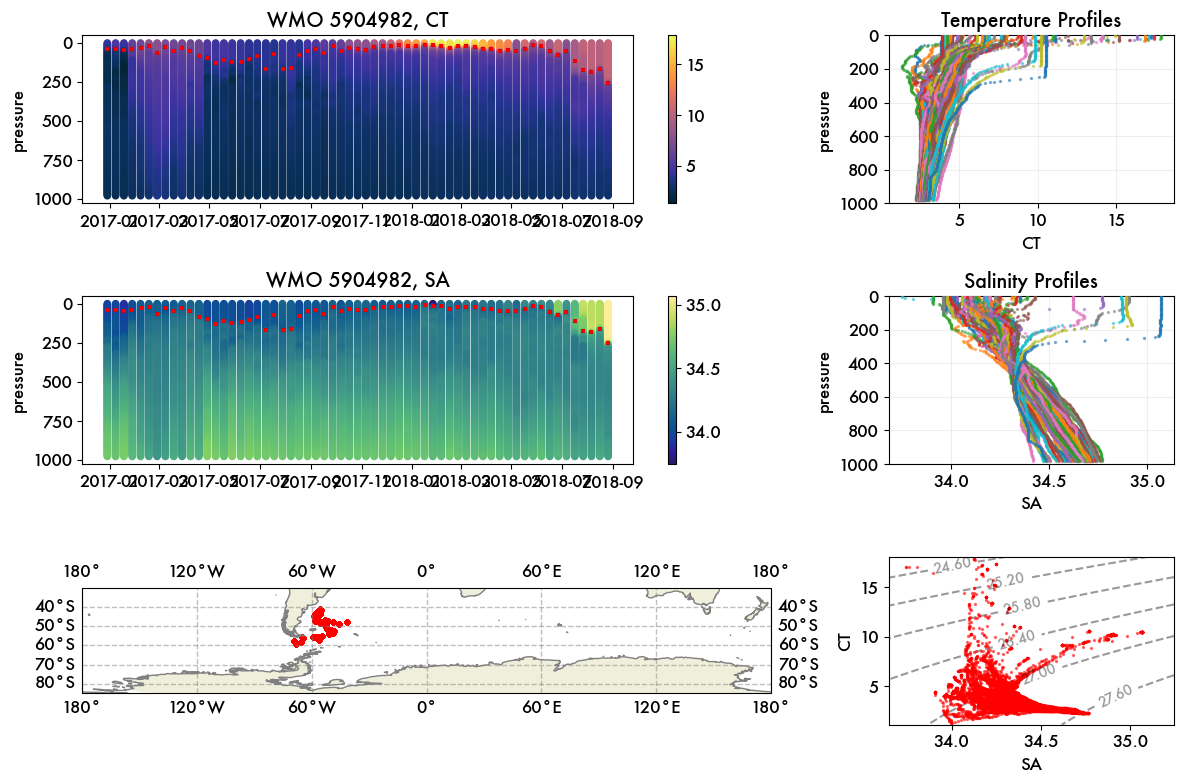

In [376]:
reload(mod_argo)

# exfloat, wmo = mod_argo.get_wmo_DS(bgcDS)   # Random float
# exfloat, wmo = mod_argo.get_wmo_DS(bgcDS, 5906526)  # Specify float
# exfloat, wmo = mod_argo.get_wmo_DS(bgcDS, wmo)  # Keep float from last run

mod_argo.plot_TS_diagnostics(exfloat.to_dataframe().reset_index(),
                            add_mlp=True)

In [ ]:
# Look at one profile 
temp = exfloat.to_dataframe().reset_index()
# temp
temp[temp.datetime > datetime.datetime(2023, 4,1)]
# temp[temp.profid == '5905370_id034']

,profid,pressure,CT,SA,sigma0,spice,temperature,salinity,yearday,latitude,longitude,pH,oxygen,wmoid,datetime,cluster,mld,mlp
5516,5906526_id033,0,6.928252,33.835794,26.389080,-0.204980,6.918223,33.676098,3382.736725,-48.510,55.652,8.025469,294.423065,5906526.0,2023-04-06 17:40:53,2.0,85.687491,86.483237
5517,5906526_id033,5,6.928252,33.835794,26.389080,-0.204980,6.918223,33.676098,3382.736725,-48.510,55.652,8.025469,294.423065,5906526.0,2023-04-06 17:40:53,2.0,85.687491,86.483237
5518,5906526_id033,10,6.928566,33.835780,26.389026,-0.204943,6.918785,33.676098,3382.736725,-48.510,55.652,8.025399,296.433388,5906526.0,2023-04-06 17:40:53,2.0,85.687491,86.483237
5519,5906526_id033,15,6.929095,33.835787,26.388961,-0.204860,6.919762,33.676098,3382.736725,-48.510,55.652,8.025981,295.189390,5906526.0,2023-04-06 17:40:53,2.0,85.687491,86.483237
5520,5906526_id033,20,6.929444,33.835778,26.388914,-0.204821,6.920571,33.676098,3382.736725,-48.510,55.652,8.025761,294.744311,5906526.0,2023-04-06 17:40:53,2.0,85.687491,86.483237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10627,5906526_id058,930,2.639229,34.562619,27.439233,-0.211862,2.698337,34.397254,3642.507604,-44.993,59.037,7.818594,183.259077,5906526.0,2023-12-22 12:10:57,2.0,26.399926,26.643497
10628,5906526_id058,935,2.634375,34.564826,27.441358,-0.210710,2.693769,34.399437,3642.507604,-44.993,59.037,7.818177,182.908994,5906526.0,2023-12-22 12:10:57,2.0,26.399926,26.643497
10629,5906526_id058,940,2.629201,34.566890,27.443397,-0.209689,2.688878,34.401478,3642.507604,-44.993,59.037,7.817764,182.585824,5906526.0,2023-12-22 12:10:57,2.0,26.399926,26.643497
10630,5906526_id058,945,2.623768,34.568800,27.445345,-0.208813,2.683735,34.403367,3642.507604,-44.993,59.037,7.817355,182.291726,5906526.0,2023-12-22 12:10:57,2.0,26.399926,26.643497


# Adding 

In [326]:
bgcINDEX

<xarray.Dataset>
Dimensions:      (profid: 11346)
Coordinates:
  * profid       (profid) object '2903453_id001' ... '6903026_id097'
Data variables: (12/20)
    pressure     (profid) float64 ...
    wmoid        (profid) float64 ...
    latitude     (profid) float64 -58.98 -58.73 -58.59 ... -48.22 -48.22 -48.2
    longitude    (profid) float64 ...
    datetime     (profid) object ...
    yearday      (profid) float64 ...
    ...           ...
    pH           (profid) float64 ...
    pH_qc        (profid) float64 ...
    pH_error     (profid) float64 ...
    bathymetry   (profid) float64 ...
    mlp          (profid) object 28.9 61.17 92.73 140.6 ... 12.15 20.83 55.04
    mld          (profid) float64 28.63 60.59 91.85 139.3 ... 12.05 20.65 54.57
Attributes:
    title:    Surface locations of bgc Argo profiles with valid surface data,...
    source:   Argopy, expert mode
    date:     20250729

In [325]:
bgcDS

<xarray.Dataset>
Dimensions:      (profid: 11346, pressure: 197)
Coordinates:
  * profid       (profid) object '2903456_id018' ... '5906567_id015'
  * pressure     (pressure) int64 0 5 10 15 20 25 30 ... 955 960 965 970 975 980
    yearday      (profid, pressure) float64 3.622e+03 3.622e+03 ... 3.391e+03
    latitude     (profid, pressure) float64 -54.48 -54.48 ... -44.81 -44.81
    longitude    (profid, pressure) float64 -143.3 -143.3 ... -165.0 -165.0
    wmoid        (profid, pressure) float64 2.903e+06 2.903e+06 ... 5.907e+06
    datetime     (profid, pressure) datetime64[ns] 2023-12-01T21:53:59 ... 20...
    cluster      (profid, pressure) float64 1.0 1.0 1.0 1.0 ... 8.0 8.0 8.0 8.0
Data variables:
    CT           (profid, pressure) float64 6.84 6.84 6.839 ... 6.116 6.086
    SA           (profid, pressure) float64 34.08 34.08 34.08 ... 34.51 34.51
    sigma0       (profid, pressure) float64 26.59 26.59 26.59 ... 27.03 27.03
    spice        (profid, pressure) float64 -0.04522 -0.04522 ... 0.1647 0.1603
    temperature  (profid, pressure) float64 6.833 6.833 6.833 ... 6.205 6.175
    salinity     (profid, pressure) float64 33.92 33.92 33.92 ... 34.35 34.35
    pH           (profid, pressure) float64 8.006 8.006 8.005 ... 7.887 7.887
    oxygen       (profid, pressure) float64 301.1 301.1 301.0 ... 220.9 220.1
    mld          (profid) float64 28.63 60.59 91.85 139.3 ... 12.05 20.65 54.57
    mlp          (profid) object 28.9 61.17 92.73 140.6 ... 12.15 20.83 55.04
Attributes:
    title:            BGC float profiles with valid data, interpolated to n=2...
    pressure_levels:  Pressure levels in dbar: [0, 5, 10, 15, 20, 25, 30, 35,...
    source:           Argopy, expert mode
    date:             20250729

## Development: checking on one profile

In [221]:
temp = exfloat.to_dataframe().reset_index()
prof_df = temp[temp.profid=='5906035_id027']

dens10 = prof_df.loc[prof_df.pressure==10].sigma0.values[0]
dens_tofind = dens10 + .03 
mask = prof_df.sigma0.values > dens_tofind

if mask.any(): # If any values meet threshold density condition
    idx = prof_df.sigma0.index[np.argmax(mask)]
    (p0,d0)= (prof_df.pressure[np.argmax(mask)-1], prof_df.sigma0[np.argmax(mask)-1]) # obs just above mlp
    (p1,d1)= (prof_df.pressure[np.argmax(mask)], prof_df.sigma0[np.argmax(mask)]) # first obs below mlp

    mlp = p1 + (dens_tofind - d1) * ((p1-p0)/(d1-d0)) # Linear interpolation

In [222]:
p0,d0

(10, 25.100977498525687)

In [223]:
p1,d1

(15, 25.141824746665275)

In [228]:
(mlp, dens_tofind)

(13.67221800321547, 25.130977498525688)

In [ ]:
# Get data from single float
# reload(mod_argo)
# exfloat, _ = mod_argo.get_wmo_DS(bgcDS, wmo=wmo)
# calc_mlp(exfloat)

(                      mlp
 5904768_id002  114.985042
 5904768_id003  114.995449
 5904768_id004  114.988292
 5904768_id005  114.979828
 5904768_id006  114.984215
 5904768_id007  129.987324
 5904768_id008  139.999616
 5904768_id009  139.995474
 5904768_id010  149.983629
 5904768_id011  159.981129
 5904768_id012  154.993051
 5904768_id013  159.979239
 5904768_id014  154.986683
 5904768_id015  144.981885
 5904768_id016  159.991012
 5904768_id017  134.990659
 5904768_id018    89.99789
 5904768_id019   94.996232
 5904768_id020   44.998841
 5904768_id021    39.99652
 5904768_id022   44.977242
 5904768_id023   39.986501
 5904768_id024   29.998958
 5904768_id025   54.988957
 5904768_id026   49.977557
 5904768_id027    39.98721
 5904768_id028   19.953833
 5904768_id029   54.973781
 5904768_id030   54.976592
 5904768_id031   69.971147
 5904768_id032   74.977867
 5904768_id033    69.97477
 5904768_id034   84.990392
 5904768_id035   89.987013
 5904768_id036    79.98882
 5904768_id037   84.977561
 

# Split data into training and validation subsets

In [35]:
import mod_regression as myreg
reload(myreg)

<module 'mod_regression' from '/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CRUSOE/src/mod_regression.py'>

In [ ]:
reload(myreg)

bgcArgo_input = bgcINDEX.where(bgcINDEX.profid.isin(bgcDS.profid.values), drop=True)

# Note bgcINDEX is the surfacemost
# Eventually want to take average of surface 20 dbar
# bgc_input = 
# bgcDS.where(bgcDS.pressure<20).mean(dim='pressure')
[trainDS, valDS, testDS] = myreg.split_training_data(bgcArgo_input, indexer = 'profid', test_split = False)

In [88]:
[trainDS_socat, valDS_socat, testDS_socat] = myreg.split_training_data(socatDS, indexer = 'sid', test_split = False)

# Preprocessing

In [79]:
import mod_ocean

## Merge socat and bgc Argo data for training

In [ ]:
# foo = trainDS.where(trainDS.pressure<20).mean(dim='pressure')
# pd.concat([foo.to_dataframe(), trainDS_socat.to_dataframe()], axis=0)

,CT,SA,sigma0,spice,temperature,salinity,pH,oxygen,longitude,latitude,...,nearest_profid,prof_datetime,prof_lat,prof_lon,yd_sep,km_sep,class,pressure,sid,cluster
2903456_id018,6.831273,34.076125,26.590125,-0.046719,6.824949,33.914994,8.005333,301.146774,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2903457_id003,12.713169,34.997032,26.322240,1.663226,12.721698,34.832602,8.044299,255.890108,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2903469_id001,10.562744,34.834319,26.598986,1.122099,10.568032,34.670718,8.029277,273.783265,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2903469_id004,10.642617,34.837982,26.587722,1.139647,10.647928,34.674361,8.036469,278.318562,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2903469_id005,11.547115,34.830548,26.417953,1.307137,11.552298,34.666964,8.037800,274.012188,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33962,16.065494,34.607579,NaN,NaN,NaN,NaN,NaN,NaN,171.6425,-46.92610,...,5906911_id011,2023-03-05,-50.49024,176.35386,5.061782,525.690553,7.0,-0.0,49616.0,8.0
33963,15.899462,34.639730,NaN,NaN,NaN,NaN,NaN,NaN,171.6426,-46.92711,...,5906911_id011,2023-03-05,-50.49024,176.35386,5.218461,525.598894,7.0,-0.0,49617.0,8.0
33964,15.769157,34.626669,NaN,NaN,NaN,NaN,NaN,NaN,171.6426,-46.92710,...,5906911_id011,2023-03-05,-50.49024,176.35386,5.356667,525.599754,7.0,-0.0,49618.0,8.0
33965,15.370297,34.584471,NaN,NaN,NaN,NaN,NaN,NaN,171.6464,-46.91864,...,5906911_id011,2023-03-05,-50.49024,176.35386,5.565694,526.144762,7.0,-0.0,49620.0,8.0


In [167]:
trainDS

<xarray.Dataset>
Dimensions:      (profid: 9076)
Coordinates:
  * profid       (profid) object '2903453_id001' ... '6903026_id097'
Data variables: (12/18)
    pressure     (profid) float64 8.28 8.13 8.14 8.09 7.89 ... 1.5 1.4 1.7 1.6
    wmoid        (profid) float64 2.903e+06 2.903e+06 ... 6.903e+06 6.903e+06
    latitude     (profid) float64 -58.98 -58.59 -58.38 ... -48.29 -48.22 -48.2
    longitude    (profid) float64 145.0 145.8 145.8 145.3 ... 65.56 65.54 65.64
    datetime     (profid) object '2023-03-31 19:36:15.002000128' ... '2020-12...
    yearday      (profid) float64 3.377e+03 3.397e+03 ... 2.548e+03 2.55e+03
    ...           ...
    time_qc      (profid) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    position_qc  (profid) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    pH           (profid) float64 8.009 8.007 8.006 7.997 ... 8.043 8.046 8.048
    pH_qc        (profid) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    pH_error     (profid) float64 0.01496 0.01497 0.015 ... 0.02202 0.022
    bathymetry   (profid) float64 -3.203e+03 -3.465e+03 ... -1.062e+03
Attributes:
    title:    Surface locations of bgc Argo profiles with valid surface data,...
    source:   Argopy, expert mode
    date:     20250729

In [168]:
trainDS_socat

<xarray.Dataset>
Dimensions:            (index: 33967)
Coordinates:
  * sid                (index) int64 156 157 159 160 ... 49617 49618 49620 49621
    cluster            (index) float64 1.0 1.0 1.0 1.0 1.0 ... 8.0 8.0 8.0 8.0
Dimensions without coordinates: index
Data variables: (12/26)
    longitude          (index) float64 13.54 13.61 13.8 ... 171.6 171.6 171.6
    latitude           (index) float64 -45.97 -45.8 -45.35 ... -46.92 -46.94
    fco2rec            (index) float64 378.1 378.3 375.6 ... 369.3 377.9 370.8
    sal                (index) float64 33.75 33.76 33.83 ... 34.46 34.42 34.47
    sst                (index) float64 7.507 7.847 8.809 ... 15.77 15.37 15.78
    yearday            (index) float64 57.59 57.67 57.92 ... 3.356e+03 3.356e+03
    ...                 ...
    yd_sep             (index) float64 5.231 5.147 4.897 ... 5.357 5.566 5.686
    km_sep             (index) float64 176.8 160.4 122.1 ... 525.6 526.1 524.5
    class              (index) float64 0.0 0.0 0.0 0.0 0.0 ... 7.0 7.0 7.0 7.0
    pressure           (index) float64 -0.0 -0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0
    SA                 (index) float64 33.91 33.92 33.99 ... 34.63 34.58 34.64
    CT                 (index) float64 7.517 7.857 8.819 ... 15.77 15.37 15.79

In [324]:
trainDS_socat.to_dataframe()

NameError: name 'trainDS_socat' is not defined

In [ ]:
training_data = pd.concat([trainDS.to_dataframe(), trainDS_socat.to_dataframe()], axis=0)
training_data = training_data[['CT', 'SA', 'latitude', 'longitude']]

,CT,SA,latitude,longitude
2903453_id001,2.881673,33.991060,-58.97770,144.9548
2903453_id003,2.812691,33.986830,-58.58640,145.7964
2903453_id004,2.544476,33.981767,-58.38220,145.7568
2903453_id007,1.397953,34.025840,-58.02160,145.2632
2903453_id008,1.542865,34.006778,-58.01150,144.9109
...,...,...,...,...
33962,16.065494,34.607579,-46.92610,171.6425
33963,15.899462,34.639730,-46.92711,171.6426
33964,15.769157,34.626669,-46.92710,171.6426
33965,15.370297,34.584471,-46.91864,171.6464


In [ ]:
# Merging the socat and bgc data
# new_index = [trainDS.profid.values] + [trainDS_socat.sid.values]
# training_data = pd.DataFrame(index = new_index)

# foo = trainDS.where(trainDS.pressure<20).mean(dim='pressure')
# xr.merge([foo, trainDS_socat])

<xarray.Dataset>
Dimensions:            (profid: 9076, index: 33967)
Coordinates:
  * profid             (profid) object '2903456_id018' ... '5906567_id015'
  * sid                (index) int64 156 157 159 160 ... 49617 49618 49620 49621
    cluster            (index) float64 1.0 1.0 1.0 1.0 1.0 ... 8.0 8.0 8.0 8.0
Dimensions without coordinates: index
Data variables: (12/31)
    CT                 (profid) float64 6.831 12.71 10.56 ... 16.2 16.61 16.03
    SA                 (profid) float64 34.08 35.0 34.83 ... 34.82 34.8 34.9
    sigma0             (profid) float64 26.59 26.32 26.6 ... 25.44 25.33 25.54
    spice              (profid) float64 -0.04672 1.663 1.122 ... 2.386 2.322
    temperature        (profid) float64 6.825 12.72 10.57 ... 16.2 16.61 16.04
    salinity           (profid) float64 33.91 34.83 34.67 ... 34.66 34.64 34.74
    ...                 ...
    prof_datetime      (index) object '2014-03-04' '2014-03-04' ... '2023-03-05'
    prof_lat           (index) float64 -44.43 -44.43 -44.43 ... -50.49 -50.49
    prof_lon           (index) float64 12.96 12.96 12.96 ... 176.4 176.4 176.4
    yd_sep             (index) float64 5.231 5.147 4.897 ... 5.357 5.566 5.686
    km_sep             (index) float64 176.8 160.4 122.1 ... 525.6 526.1 524.5
    class              (index) float64 0.0 0.0 0.0 0.0 0.0 ... 7.0 7.0 7.0 7.0

# Single RFR

In [ ]:
# # 3.3.1 Initialize variables to train the different models on 
# var_list = {
#             'Model_B': ['CT', 'SA', 'pressure'], 
#             'Model_C': ["CT", "SA", "pressure", 'oxygen'],
#             'Model_D': ["CT", "SA", "pressure", "oxygen", 'lat', 'lon', 'yearday'],
#             'Model_E': ["CT", "SA", 'pressure', 'oxygen', 'lat', 'lon', 'yearday', 'o2sat'],
#             'Model_F': ["CT", "SA", 'pressure', 'oxygen', 'lat', 'lon', 'yearday', 'log_buoyancy'],
#             'Model_G': ["CT", "SA", 'pressure', 'oxygen', 'lat', 'lon', 'yearday', 'ydcos', 'ydsin']
#             }

# model_list = list(var_list.keys())

# # Create dictionary of features
# allvars = []
# for k in var_list.keys():
#     allvars = allvars + var_list[str(k)]
# allvars = pd.unique(allvars)

# # Color palettes for each model
# from mod_plot import model_palettes